# LSEG/Gemma hybrid long-leg characteristic attribution

**Objective.** Explain Notebook 60's unchanged selected-long minus same-sector
gross advantage using conventional strictly lagged price and liquidity
characteristics. The selected dates, names, weights, universe, and one-session
return remain exactly those of the Gemma-timing/FinBERT-ranking hybrid. This is
a post-result confound audit, not a new strategy or independent confirmation.

## Frozen design

The source-controlled specification was committed before this adjusted outcome
was opened. Within each session-sector cell, demean next-open returns and four
point-in-time characteristics: lagged 1-session return, lagged 5-session return,
20-session volatility, and log 20-session ADV. Fit one joint no-intercept model
on nonselected names only. The primary estimand is the selected-weighted residual
mean over all 167 sessions. Its 9,999-replication five-session circular-block
bootstrap refits the characteristic coefficients inside every resample. There is
one new primary test and no multiplicity search.

In [1]:
from __future__ import annotations

import hashlib
import json
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "final_experiments":
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from final_experiments.lib.characteristic_attribution import (  # noqa: E402
    FEATURE_COLUMNS,
    bootstrap_residual_mean,
    build_lagged_characteristics,
    fit_characteristic_attribution,
)
from final_experiments.lib.evaluate import annualized_sharpe  # noqa: E402
from final_experiments.lib.plots import CATEGORICAL, INK, apply_house_style  # noqa: E402
from final_experiments.lib.sector_portfolios import SECTOR_MEMBERS  # noqa: E402
from final_experiments.lib.sparse_spread import build_exact_extrema_targets  # noqa: E402
from sentiment_benchmark.artifact_io import sha256_file  # noqa: E402

SPEC_PATH = REPO_ROOT / "final_experiments/frozen_specs/lseg_gemma_hybrid_long_leg_characteristic_attribution_v1.json"
AGGREGATE_DIR = REPO_ROOT / "final_experiments/outputs/13_lseg_44_gemma_robustness"
GEMMA_PATH = AGGREGATE_DIR / "gemma4_26b_firm_open_aggregators.parquet"
FINBERT_PATH = AGGREGATE_DIR / "finbert_firm_open_aggregators.parquet"
PRICE_PATH = REPO_ROOT / "Data/derived/prices/lseg_us_sector_33_8m.csv"
PRICE_MANIFEST_PATH = REPO_ROOT / "Data/derived/prices/lseg_us_sector_33_8m.manifest.json"
NOTEBOOK60_DAILY = REPO_ROOT / "final_experiments/outputs/60_lseg_gemma_hybrid_long_leg_exposure_control/daily_control_audit.parquet"
OUTPUT_DIR = REPO_ROOT / "final_experiments/outputs/63_lseg_gemma_hybrid_long_leg_characteristic_attribution"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

spec = json.loads(SPEC_PATH.read_text())
assert spec["status"] == "frozen_before_characteristic_adjusted_outcome"
SEED = int(spec["inference"]["seed"])
BLOCK_LENGTH = int(spec["inference"]["block_length_sessions"])
REPLICATIONS = int(spec["inference"]["replications"])
SINGLE_NAME_CAP = 0.25
IDENTITY_TOLERANCE = float(spec["attribution"]["identity_tolerance"])
apply_house_style()
pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", lambda value: f"{value:,.6f}")

## Reconstruct the unchanged LSEG/Gemma-FinBERT long leg

Gemma fixes each session's positive/negative event counts; FinBERT fixes the
cross-sectional names. Price returns are recomputed from the validated local
open series. No headline text is loaded or emitted.

In [2]:
sector_members = {sector: tuple(members[:3]) for sector, members in SECTOR_MEMBERS.items()}
symbols = tuple(sorted(symbol for members in sector_members.values() for symbol in members))
sector_by_symbol = {symbol: sector for sector, members in sector_members.items() for symbol in members}
if len(symbols) != 33 or len(sector_members) != 11 or any(len(members) != 3 for members in sector_members.values()):
    raise ValueError("expected immutable original 33 in eleven three-company sectors")

gemma = pd.read_parquet(GEMMA_PATH)
finbert = pd.read_parquet(FINBERT_PATH)
for frame in (gemma, finbert):
    frame["session_date"] = pd.to_datetime(frame["session_date"]).dt.normalize()
gemma = gemma.loc[gemma["symbol"].isin(symbols)].copy()
finbert = finbert.loc[finbert["symbol"].isin(symbols)].copy()
if not gemma[["session_date", "symbol"]].equals(finbert[["session_date", "symbol"]]):
    raise ValueError("paired scorer panels are not row-aligned")
if gemma.duplicated(["session_date", "symbol"]).any() or finbert["strongest_event"].isna().any():
    raise ValueError("candidate scorer input is invalid")
sessions = pd.DatetimeIndex(sorted(gemma["session_date"].unique()))
if len(sessions) != 167 or set(gemma["symbol"].unique()) != set(symbols):
    raise ValueError("expected 167 sessions and immutable original 33")

prices = pd.read_csv(PRICE_PATH, parse_dates=["session_date"])
prices["session_date"] = pd.to_datetime(prices["session_date"]).dt.normalize()
prices = prices.loc[prices["symbol"].isin(symbols)].copy()
price_manifest = json.loads(PRICE_MANIFEST_PATH.read_text())
assert price_manifest["return_convention"] == "split-adjusted price returns; dividends not back-adjusted"
assert sha256_file(PRICE_PATH) == price_manifest["file"]["sha256"]
open_wide = prices.pivot(index="session_date", columns="symbol", values="open").sort_index().dropna()
locations = open_wide.index.get_indexer(sessions)
if (locations < 0).any() or not np.array_equal(locations[1:], locations[:-1] + 1):
    raise ValueError("signal sessions are not consecutive complete-price sessions")
if locations[-1] + 1 >= len(open_wide):
    raise ValueError("last signal session has no following open")
next_sessions = open_wide.index[locations + 1]
current_open = open_wide.loc[sessions, list(symbols)].to_numpy(dtype=float)
next_open = open_wide.loc[next_sessions, list(symbols)].to_numpy(dtype=float)
return_matrix = next_open / current_open - 1.0

def rank_map(frame: pd.DataFrame) -> dict[pd.Timestamp, tuple[str, ...]]:
    result = {
        pd.Timestamp(session): tuple(
            day.sort_values(
                ["strongest_event", "symbol"], ascending=[False, True], kind="mergesort"
            )["symbol"]
        )
        for session, day in frame.groupby("session_date", sort=True)
    }
    if len(result) != len(sessions) or any(set(row) != set(symbols) for row in result.values()):
        raise ValueError("rank map is incomplete")
    return result

_, target_audit = build_exact_extrema_targets(gemma, single_name_cap=SINGLE_NAME_CAP)
if not np.array_equal(pd.to_datetime(target_audit["session_date"]).to_numpy(), sessions.to_numpy()):
    raise ValueError("target audit is not aligned to the session spine")
ranks = rank_map(finbert)
symbol_index = {symbol: index for index, symbol in enumerate(symbols)}
selected_weights = np.zeros((len(sessions), len(symbols)), dtype=float)
for row_index, row in enumerate(target_audit.itertuples(index=False)):
    n_long, n_short, eligible = int(row.positive_names), int(row.negative_names), bool(row.eligible)
    if not eligible:
        continue
    ranked = ranks[pd.Timestamp(row.session_date)]
    long_symbols = ranked[:n_long]
    short_symbols = ranked[-n_short:]
    if not n_long or not n_short or set(long_symbols) & set(short_symbols):
        raise RuntimeError("invalid hybrid rank selection")
    leg_exposure = min(0.5, SINGLE_NAME_CAP * n_long, SINGLE_NAME_CAP * n_short)
    for symbol in long_symbols:
        selected_weights[row_index, symbol_index[symbol]] = leg_exposure / n_long
if selected_weights.min() < 0 or selected_weights.max() > SINGLE_NAME_CAP + IDENTITY_TOLERANCE:
    raise RuntimeError("selected long weights violate frozen bounds")

## Build point-in-time characteristics and the attribution panel

Every nonzero selected weight must have all four characteristics. Early rows
without sufficient history may remain only when the strategy is inactive. The
sector-demeaned raw path must reproduce Notebook 60 exactly.

In [3]:
characteristics = build_lagged_characteristics(
    prices,
    window_sessions=20,
    minimum_observations=5,
)
index = pd.MultiIndex.from_product([sessions, symbols], names=["session_date", "symbol"])
panel = index.to_frame(index=False)
panel["sector"] = panel["symbol"].map(sector_by_symbol)
panel["forward_return"] = return_matrix.reshape(-1)
panel["selected_weight"] = selected_weights.reshape(-1)
panel = panel.merge(characteristics, on=["session_date", "symbol"], how="left", validate="1:1")
selected = panel["selected_weight"].gt(0)
if panel.loc[selected, list(FEATURE_COLUMNS)].isna().any().any():
    raise ValueError("selected rows lack frozen point-in-time characteristics")

attribution = fit_characteristic_attribution(
    panel,
    identity_tolerance=IDENTITY_TOLERANCE,
)
daily = attribution.daily.copy()
daily["return_end_date"] = next_sessions
n60 = pd.read_parquet(NOTEBOOK60_DAILY).reset_index(drop=True)
n60["session_date"] = pd.to_datetime(n60["session_date"]).dt.normalize()
if not np.array_equal(n60["session_date"].to_numpy(), daily["session_date"].to_numpy()):
    raise ValueError("Notebook 60 daily path is not aligned")
reference = n60["selected_minus_same_sector"].to_numpy(dtype=float)
reference_error = float(np.max(np.abs(reference - daily["raw_sector_difference"].to_numpy(dtype=float))))
if reference_error > IDENTITY_TOLERANCE:
    raise RuntimeError("sector-demeaned path does not reproduce Notebook 60")
coverage = pd.DataFrame(
    [
        {
            "sessions": len(daily),
            "active_sessions": int(daily["selected_names"].gt(0).sum()),
            "firm_session_rows": len(panel),
            "complete_characteristic_rows": int(panel[list(FEATURE_COLUMNS)].notna().all(axis=1).sum()),
            "selected_rows": int(selected.sum()),
            "selected_rows_with_complete_characteristics": int(panel.loc[selected, list(FEATURE_COLUMNS)].notna().all(axis=1).sum()),
            "notebook60_identity_max_error": reference_error,
            "licensed_headline_text_loaded": False,
        }
    ]
)
display(coverage.T)
display(attribution.scaling)

,0
sessions,167
active_sessions,70
firm_session_rows,5511
complete_characteristic_rows,5449
selected_rows,125
selected_rows_with_complete_characteristics,125
notebook60_identity_max_error,0.000000
licensed_headline_text_loaded,False


,feature,mean,std
0,lagged_return_1,0.000496,0.019582
1,lagged_return_5,0.003039,0.042885
2,sigma20,0.018165,0.007666
3,log_adv20,20.695456,1.640288


## Primary characteristic-adjusted result

The raw sector difference is a locked identity reference, not a newly tested
arm. The only new inferential result is the residual after joint adjustment.
Chronological halves are descriptive stability checks fixed in the contract.

In [4]:
bootstrap_metrics, bootstrap_distribution = bootstrap_residual_mean(
    attribution,
    block_length=BLOCK_LENGTH,
    replications=REPLICATIONS,
    seed=SEED,
)
split = (len(daily) + 1) // 2
paths = {
    "raw_within_sector_difference": "raw_sector_difference",
    "explained_by_characteristics": "explained_characteristic_component",
    "characteristic_adjusted_residual": "residual_characteristic_adjusted",
}
summary_rows = []
for path, column in paths.items():
    values = daily[column].to_numpy(dtype=float)
    summary_rows.append(
        {
            "path": path,
            "mean_bps_session": float(values.mean() * 10_000),
            "sharpe_all_sessions": float(annualized_sharpe(pd.Series(values))),
            "first_half_mean_bps_session": float(values[:split].mean() * 10_000),
            "second_half_mean_bps_session": float(values[split:].mean() * 10_000),
            "arithmetic_total": float(values.sum()),
        }
    )
summary = pd.DataFrame(summary_rows)
residual_row = summary.set_index("path").loc["characteristic_adjusted_residual"]
ci_low_bps = float(bootstrap_metrics["ci_low"] * 10_000)
ci_high_bps = float(bootstrap_metrics["ci_high"] * 10_000)
if residual_row["mean_bps_session"] <= 0:
    interpretation_class = "explained_or_nonpositive"
elif ci_low_bps > 0 and residual_row["first_half_mean_bps_session"] > 0 and residual_row["second_half_mean_bps_session"] > 0:
    interpretation_class = "robust_residual"
else:
    interpretation_class = "positive_uncertain"
inference = pd.DataFrame(
    [
        {
            "estimand": "mean_characteristic_adjusted_residual",
            "mean_bps_session": float(residual_row["mean_bps_session"]),
            "ci_low_bps_session": ci_low_bps,
            "ci_high_bps_session": ci_high_bps,
            "p_two_sided": float(bootstrap_metrics["p_two_sided"]),
            "block_length": BLOCK_LENGTH,
            "replications": REPLICATIONS,
            "seed": SEED,
            "interpretation_class": interpretation_class,
        }
    ]
)
display(summary)
display(inference.T)
display(attribution.coefficients)

,path,mean_bps_session,sharpe_all_sessions,first_half_mean_bps_session,second_half_mean_bps_session,arithmetic_total
0,raw_within_sector_difference,3.661933,3.076815,5.321439,1.982432,0.061154
1,explained_by_characteristics,-0.073150,-2.414438,-0.013317,-0.133704,-0.001222
2,characteristic_adjusted_residual,3.735083,3.143550,5.334757,2.116136,0.062376


,0
estimand,mean_characteristic_adjusted_residual
mean_bps_session,3.735083
ci_low_bps_session,0.867082
ci_high_bps_session,6.745608
p_two_sided,0.008600
block_length,5
replications,9999
seed,20260820
interpretation_class,robust_residual


,feature,coefficient_return_per_sd,mean_selected_exposure_sd_weight,mean_explained_bps_session
0,lagged_return_1,-0.000500,0.025656,-0.128332
1,lagged_return_5,0.000157,0.028248,0.044374
2,sigma20,0.000103,0.013977,0.014427
3,log_adv20,0.000031,-0.011738,-0.003619


## Attribution figures and evidence hand-off

Cumulative arithmetic paths show how much of Notebook 60's gross difference is
associated with the frozen characteristic model. Feature bars are descriptive;
they are not separately tested or used to redesign the candidate.

findfont: Failed to find font weight medium, now using 400.


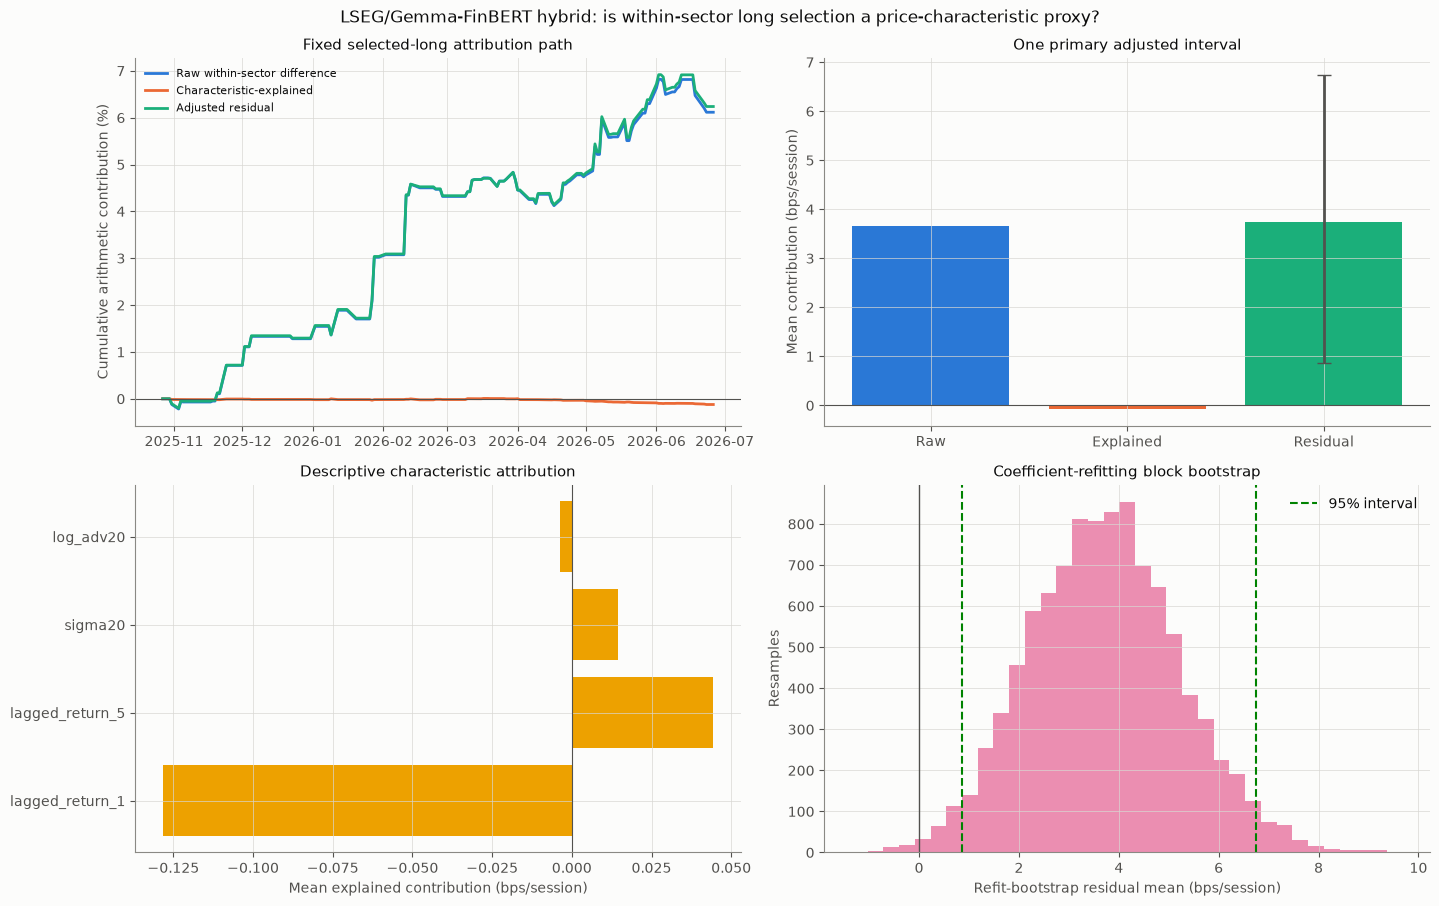

### Decision

- Raw within-sector selected-long difference: **+3.66 bps/session**.
- Joint price/liquidity-explained component: **-0.07 bps/session**.
- Adjusted residual: **+3.74 bps/session** [**+0.87**, **+6.75**], p=**0.0086**; classification **robust_residual**.
- This is explanatory evidence only: no weights, costs, strategy, or prospective contract changed.

{
  "interpretation_class": "robust_residual",
  "raw_sector_difference_bps_session": 3.6619327346980057,
  "characteristic_explained_bps_session": -0.07315021326065858,
  "adjusted_residual_bps_session": 3.7350829479586647,
  "adjusted_residual_ci_low_bps_session": 0.8670821796032082,
  "adjusted_residual_ci_high_bps_session": 6.74560787938356,
  "adjusted_residual_p_two_sided": 0.0086,
  "adjusted_residual_first_half_bps_session": 5.334756527928833,
  "adjusted_residual_second_half_bps_session": 2.1161361923262056,
  "new_signal_constructed": false,
  "new_traded_strategy_constructed": false,
  "prospective_contract_changed": false,
  "validated_alpha": false
}


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14.5, 9.2))
for label, column, color in (
    ("Raw within-sector difference", "raw_sector_difference", CATEGORICAL[0]),
    ("Characteristic-explained", "explained_characteristic_component", CATEGORICAL[1]),
    ("Adjusted residual", "residual_characteristic_adjusted", CATEGORICAL[2]),
):
    axes[0, 0].plot(daily["session_date"], 100 * daily[column].cumsum(), lw=2, label=label, color=color)
axes[0, 0].axhline(0, color=INK["reference"], lw=0.8)
axes[0, 0].set_ylabel("Cumulative arithmetic contribution (%)")
axes[0, 0].set_title("Fixed selected-long attribution path")
axes[0, 0].legend(frameon=False, fontsize=8)

axes[0, 1].bar(
    ["Raw", "Explained", "Residual"],
    summary["mean_bps_session"],
    color=CATEGORICAL[:3],
)
axes[0, 1].errorbar(
    2,
    residual_row["mean_bps_session"],
    yerr=[[residual_row["mean_bps_session"] - ci_low_bps], [ci_high_bps - residual_row["mean_bps_session"]]],
    fmt="none", color=INK["reference"], capsize=5,
)
axes[0, 1].axhline(0, color=INK["reference"], lw=0.8)
axes[0, 1].set_ylabel("Mean contribution (bps/session)")
axes[0, 1].set_title("One primary adjusted interval")

feature_plot = attribution.coefficients.set_index("feature")["mean_explained_bps_session"]
axes[1, 0].barh(feature_plot.index, feature_plot.values, color=CATEGORICAL[3])
axes[1, 0].axvline(0, color=INK["reference"], lw=0.8)
axes[1, 0].set_xlabel("Mean explained contribution (bps/session)")
axes[1, 0].set_title("Descriptive characteristic attribution")

axes[1, 1].hist(bootstrap_distribution * 10_000, bins=35, color=CATEGORICAL[4], alpha=0.85)
axes[1, 1].axvline(0, color=INK["reference"], lw=1)
axes[1, 1].axvline(ci_low_bps, color=CATEGORICAL[5], ls="--", lw=1.5, label="95% interval")
axes[1, 1].axvline(ci_high_bps, color=CATEGORICAL[5], ls="--", lw=1.5)
axes[1, 1].set_xlabel("Refit-bootstrap residual mean (bps/session)")
axes[1, 1].set_ylabel("Resamples")
axes[1, 1].set_title("Coefficient-refitting block bootstrap")
axes[1, 1].legend(frameon=False)
fig.suptitle("LSEG/Gemma-FinBERT hybrid: is within-sector long selection a price-characteristic proxy?")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "long_leg_characteristic_attribution.png", dpi=180, bbox_inches="tight")
plt.show()

coverage.to_csv(OUTPUT_DIR / "coverage.csv", index=False)
summary.to_csv(OUTPUT_DIR / "attribution_summary.csv", index=False)
inference.to_csv(OUTPUT_DIR / "residual_inference.csv", index=False)
attribution.coefficients.to_csv(OUTPUT_DIR / "characteristic_coefficients.csv", index=False)
attribution.scaling.to_csv(OUTPUT_DIR / "characteristic_scaling.csv", index=False)
daily.to_parquet(OUTPUT_DIR / "daily_attribution_audit.parquet", index=False)
decision = {
    "interpretation_class": interpretation_class,
    "raw_sector_difference_bps_session": float(summary.loc[summary["path"].eq("raw_within_sector_difference"), "mean_bps_session"].iloc[0]),
    "characteristic_explained_bps_session": float(summary.loc[summary["path"].eq("explained_by_characteristics"), "mean_bps_session"].iloc[0]),
    "adjusted_residual_bps_session": float(residual_row["mean_bps_session"]),
    "adjusted_residual_ci_low_bps_session": ci_low_bps,
    "adjusted_residual_ci_high_bps_session": ci_high_bps,
    "adjusted_residual_p_two_sided": float(bootstrap_metrics["p_two_sided"]),
    "adjusted_residual_first_half_bps_session": float(residual_row["first_half_mean_bps_session"]),
    "adjusted_residual_second_half_bps_session": float(residual_row["second_half_mean_bps_session"]),
    "new_signal_constructed": False,
    "new_traded_strategy_constructed": False,
    "prospective_contract_changed": False,
    "validated_alpha": False,
}
try:
    git_commit = subprocess.run(
        ["git", "rev-parse", "HEAD"], cwd=REPO_ROOT, check=True, capture_output=True, text=True
    ).stdout.strip()
except (OSError, subprocess.CalledProcessError):
    git_commit = None
aggregate_files = [
    "coverage.csv",
    "attribution_summary.csv",
    "residual_inference.csv",
    "characteristic_coefficients.csv",
    "characteristic_scaling.csv",
    "long_leg_characteristic_attribution.png",
]
manifest = {
    "status": "RETROSPECTIVE_OPENED_WINDOW_CHARACTERISTIC_ATTRIBUTION",
    "notebook": "63_lseg_gemma_hybrid_long_leg_characteristic_attribution.ipynb",
    "git_commit_at_execution": git_commit,
    "frozen_spec_sha256": sha256_file(SPEC_PATH),
    "specification": spec,
    "input_boundary": {
        "gemma_aggregate_panel": str(GEMMA_PATH.relative_to(REPO_ROOT)),
        "finbert_aggregate_panel": str(FINBERT_PATH.relative_to(REPO_ROOT)),
        "price_path": str(PRICE_PATH.relative_to(REPO_ROOT)),
        "notebook60_daily": str(NOTEBOOK60_DAILY.relative_to(REPO_ROOT)),
        "licensed_headline_text_loaded": False,
        "licensed_text_emitted": False,
        "source_regimes_pooled": False,
        "row_level_attribution_persisted_local_only": True,
    },
    "coverage": json.loads(coverage.to_json(orient="records"))[0],
    "summary": json.loads(summary.to_json(orient="records")),
    "inference": json.loads(inference.to_json(orient="records"))[0],
    "coefficients": json.loads(attribution.coefficients.to_json(orient="records")),
    "decision": decision,
    "claim_boundary": spec["claim_boundary"],
    "limitations": [
        "The candidate, outcome window, long-leg focus, and sector-control result were already opened.",
        "The pooled descriptive coefficients use the same historical window and are not a tradable point-in-time factor model.",
        "The four controls do not exhaust size, beta, earnings, fundamental, or latent factor confounding.",
        "Gross arithmetic attribution omits costs and cannot promote a long-only or residual strategy.",
        "Human semantic validation and genuinely new-date replay remain required.",
    ],
    "files": {name: sha256_file(OUTPUT_DIR / name) for name in aggregate_files},
}
(OUTPUT_DIR / "manifest.json").write_text(json.dumps(manifest, indent=2) + "\n")
display(Markdown(
    "### Decision\n\n"
    f"- Raw within-sector selected-long difference: **{decision['raw_sector_difference_bps_session']:+.2f} bps/session**.\n"
    f"- Joint price/liquidity-explained component: **{decision['characteristic_explained_bps_session']:+.2f} bps/session**.\n"
    f"- Adjusted residual: **{decision['adjusted_residual_bps_session']:+.2f} bps/session** "
    f"[**{decision['adjusted_residual_ci_low_bps_session']:+.2f}**, **{decision['adjusted_residual_ci_high_bps_session']:+.2f}**], "
    f"p=**{decision['adjusted_residual_p_two_sided']:.4f}**; classification **{interpretation_class}**.\n"
    "- This is explanatory evidence only: no weights, costs, strategy, or prospective contract changed."
))
print(json.dumps(decision, indent=2))

## Next step

If the residual is robust, retain it only as stronger opened-window evidence
that the selected long names are not a simple sector/price/liquidity proxy. If
it is uncertain or nonpositive, narrow the mechanism claim. In every case, stop
historical control expansion and leave the frozen prospective hybrid unchanged.